Device: cpu

── Label distribution ──────────────────
  NORMAL (0): 2107  (95.3%)
  SPIKE  (1):   32  (1.4%)
  CRASH  (2):   40  (1.8%)
  BUBBLE (3):   33  (1.5%)

── Splits ──────────────────────────────
  Train 1769  2017-06-19 → 2024-07-02
  Val    221  2024-07-03 → 2025-05-19
  Test   222  2025-05-20 → 2026-04-07

── Window tensors ──────────────────────
  Train: X=(1739, 30, 13)  y=(1739,)
  Val  : X=(191, 30, 13)  y=(191,)
  Test : X=(192, 30, 13)  y=(192,)

── [1/3] Training Transformer ──────────
  Transformer class weights: {'NORMAL': 0.26, 'SPIKE': 33.44, 'CRASH': 26.35, 'BUBBLE': 24.15}
  Ep 1/25  tr_loss=2.5270 tr_acc=0.077  va_loss=4.2718 va_acc=0.016  ✓
  Ep 2/25  tr_loss=2.6805 tr_acc=0.071  va_loss=4.3611 va_acc=0.016
  Ep 3/25  tr_loss=2.3541 tr_acc=0.042  va_loss=4.2573 va_acc=0.016
  Ep 4/25  tr_loss=2.4927 tr_acc=0.031  va_loss=4.3225 va_acc=0.000
  Ep 5/25  tr_loss=2.5368 tr_acc=0.049  va_loss=4.3103 va_acc=0.016
  Ep 6/25  tr_loss=2.2236 tr_acc=0.028  va_loss=4.23

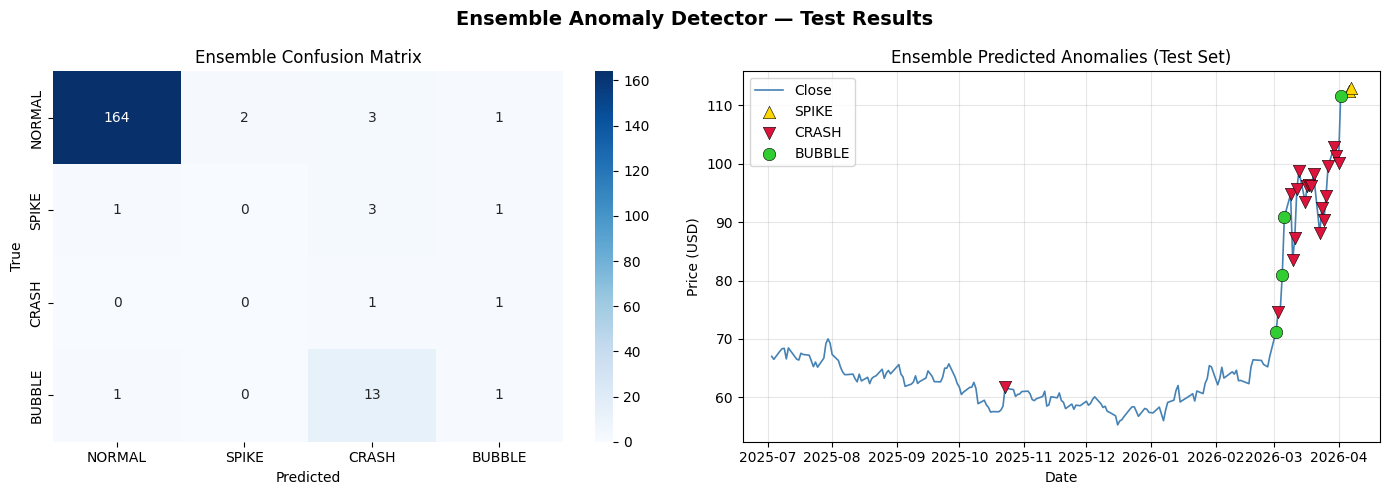

  Plot saved → ensemble_results.png

── Sample Predictions ──────────────────

  ┌─ 2025-07-03  [true: NORMAL]
  │  Ensemble Verdict : ✅ NORMAL  (54.3%)
  │  ────────────────────────────────────────
  │  Transformer : CRASH   (33.9%)
  │  XGBoost     : NORMAL  (100.0%)
  │  ISO score   : 0.460  (normal)
  │  ────────────────────────────────────────
  │  NORMAL :  54.3%  █████████████
  │  SPIKE  :  15.4%  ███
  │  CRASH  :  29.4%  ███████
  │  BUBBLE :   1.0%  
  └──────────────────────────────────────────────

  ┌─ 2025-09-10  [true: NORMAL]
  │  Ensemble Verdict : ✅ NORMAL  (74.8%)
  │  ────────────────────────────────────────
  │  Transformer : CRASH   (35.9%)
  │  XGBoost     : NORMAL  (100.0%)
  │  ISO score   : 0.370  (normal)
  │  ────────────────────────────────────────
  │  NORMAL :  74.8%  █████████████████
  │  SPIKE  :   9.6%  ██
  │  CRASH  :  15.6%  ███
  │  BUBBLE :   0.0%  
  └──────────────────────────────────────────────

  ┌─ 2025-11-17  [true: NORMAL]
  │  Ensemble 

In [8]:
"""
Ensemble Market Anomaly Detection Pipeline
============================================
Strategy:
  - Transformer  → best at NORMAL & BUBBLE (sequence context)
  - XGBoost      → best at SPIKE & CRASH   (sharp statistical features)
  - Isolation Forest → unsupervised anomaly score (extra signal for rare events)
  - Meta-Classifier (Logistic Regression) → combines all three

Why this works for SPIKE/CRASH:
  Spikes/crashes are single-day outliers — raw statistical features
  (z-score, ATR, volume shock) carry more signal than 30-day sequences.
  XGBoost + IsolationForest captures that directly.

Split: 80% train | 10% val | 10% test
"""

import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import xgboost as xgb

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

# ──────────────────────────────────────────────────────
# CONFIG
# ──────────────────────────────────────────────────────
WINDOW    = 30
EPOCHS    = 25
BATCH     = 64
LR        = 3e-4
PATIENCE  = 6
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LABEL_MAP = {0:"NORMAL", 1:"SPIKE", 2:"CRASH", 3:"BUBBLE"}

# Transformer sequence features
SEQ_FEAT = [
    "Return","LogReturn","Range",
    "MA5_ratio","MA20_ratio","MA50_ratio",
    "Volatility5","Volatility20","RSI","MACD",
    "VolumeRatio","Momentum5","Momentum20"
]

# XGBoost point features — engineered for sharp single-day moves
XGB_FEAT = [
    "Return","LogReturn","Range","RSI","MACD",
    "VolumeRatio","Momentum5","Momentum20",
    "ZScore5","ZScore20",          # how many σ from rolling mean
    "ATR14",                        # Average True Range
    "VolumeSurge",                  # volume vs 5-day avg
    "PriceAccel",                   # second derivative of price
    "GapOpen",                      # overnight gap
    "UpperShadow","LowerShadow",    # candlestick shadows
]

print(f"Device: {DEVICE}\n")

# ──────────────────────────────────────────────────────
# 1. FEATURE ENGINEERING
# ──────────────────────────────────────────────────────
def engineer(path):
    df = pd.read_csv(path, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
    c  = df["Close"]; h = df["High"]; l = df["Low"]; o = df["Open"]

    # Base features
    df["Return"]       = c.pct_change()
    df["LogReturn"]    = np.log(c / c.shift(1))
    df["Range"]        = (h - l) / c
    df["MA5"]          = c.rolling(5).mean()
    df["MA20"]         = c.rolling(20).mean()
    df["MA50"]         = c.rolling(50).mean()
    df["MA5_ratio"]    = c / df["MA5"]
    df["MA20_ratio"]   = c / df["MA20"]
    df["MA50_ratio"]   = c / df["MA50"]
    df["Volatility5"]  = df["Return"].rolling(5).std()
    df["Volatility20"] = df["Return"].rolling(20).std()
    d = c.diff()
    g = d.clip(lower=0).rolling(14).mean()
    ls = (-d.clip(upper=0)).rolling(14).mean()
    df["RSI"]          = 100 - 100 / (1 + g / (ls + 1e-9))
    df["MACD"]         = c.ewm(span=12).mean() - c.ewm(span=26).mean()
    df["VolumeRatio"]  = df["Volume"] / df["Volume"].rolling(20).mean()
    df["Momentum5"]    = c / c.shift(5)  - 1
    df["Momentum20"]   = c / c.shift(20) - 1

    # Extra spike/crash features
    roll5_mean         = df["Return"].rolling(5).mean()
    roll5_std          = df["Return"].rolling(5).std()
    roll20_mean        = df["Return"].rolling(20).mean()
    roll20_std         = df["Return"].rolling(20).std()
    df["ZScore5"]      = (df["Return"] - roll5_mean)  / (roll5_std  + 1e-9)
    df["ZScore20"]     = (df["Return"] - roll20_mean) / (roll20_std + 1e-9)

    # ATR14
    tr                 = pd.concat([h-l, (h-c.shift()).abs(), (l-c.shift()).abs()], axis=1).max(axis=1)
    df["ATR14"]        = tr.rolling(14).mean() / c

    df["VolumeSurge"]  = df["Volume"] / (df["Volume"].rolling(5).mean() + 1e-9)
    df["PriceAccel"]   = df["Return"] - df["Return"].shift(1)
    df["GapOpen"]      = (o - c.shift()) / (c.shift() + 1e-9)
    df["UpperShadow"]  = (h - pd.concat([c, o], axis=1).max(axis=1)) / (c + 1e-9)
    df["LowerShadow"]  = (pd.concat([c, o], axis=1).min(axis=1) - l)  / (c + 1e-9)

    return df.dropna().reset_index(drop=True)

# ──────────────────────────────────────────────────────
# 2. ANOMALY LABELLING
# ──────────────────────────────────────────────────────
def label(df):
    ret   = df["Return"]
    sigma = ret.std()
    y     = np.zeros(len(df), dtype=int)
    y[(df["MA50_ratio"] > 1.10) & (df["Momentum20"] > 0.30)] = 3  # BUBBLE
    y[ret >  2 * sigma] = 1                                         # SPIKE
    y[ret < -2 * sigma] = 2                                         # CRASH
    df = df.copy(); df["Label"] = y
    print("── Label distribution ──────────────────")
    for k, v in LABEL_MAP.items():
        n = (y == k).sum()
        print(f"  {v:7s}({k}): {n:4d}  ({100*n/len(y):.1f}%)")
    return df

# ──────────────────────────────────────────────────────
# 3. SLIDING WINDOW DATASET  (for Transformer)
# ──────────────────────────────────────────────────────
class WindowDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

def make_windows(df, scaler=None, fit=False):
    v = df[SEQ_FEAT].values.astype(np.float32)
    if fit: scaler = StandardScaler(); v = scaler.fit_transform(v)
    else:   v = scaler.transform(v)
    X, y = [], []
    for i in range(WINDOW, len(df)):
        X.append(v[i-WINDOW:i])




        
        HORIZON = 3
        y.append(int(df["Label"].iloc[min(i + HORIZON, len(df)-1)]))
    return np.array(X), np.array(y, dtype=np.int64), scaler

# ──────────────────────────────────────────────────────
# 4. TRANSFORMER MODEL  (unchanged — good at NORMAL/BUBBLE)
# ──────────────────────────────────────────────────────
class PosEnc(nn.Module):
    def __init__(self, d, maxlen=512, p=0.1):
        super().__init__()
        self.drop = nn.Dropout(p)
        pe  = torch.zeros(maxlen, d)
        pos = torch.arange(maxlen).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d, 2).float() * (-math.log(10000) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x): return self.drop(x + self.pe[:, :x.size(1)])

class AnomalyTransformer(nn.Module):
    def __init__(self, in_dim, seq_len, d=128, heads=4, layers=3, ff=256, drop=0.2, nc=4):
        super().__init__()
        self.proj = nn.Linear(in_dim, d)
        self.cls  = nn.Parameter(torch.zeros(1, 1, d))
        self.pos  = PosEnc(d, seq_len+1, drop)
        enc_layer = nn.TransformerEncoderLayer(d, heads, ff, drop,
                      activation="gelu", batch_first=True, norm_first=True)
        self.enc  = nn.TransformerEncoder(enc_layer, layers, enable_nested_tensor=False)
        self.head = nn.Sequential(
            nn.LayerNorm(d), nn.Dropout(drop),
            nn.Linear(d, 64), nn.GELU(), nn.Linear(64, nc))
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
        nn.init.trunc_normal_(self.cls, std=0.02)

    def forward(self, x):
        B = x.size(0)
        h = self.proj(x)
        h = torch.cat([self.cls.expand(B, -1, -1), h], dim=1)
        h = self.pos(h); h = self.enc(h)
        return self.head(h[:, 0])

# ──────────────────────────────────────────────────────
# 5. TRAIN / EVAL HELPERS
# ──────────────────────────────────────────────────────
def train_epoch(model, loader, opt, crit):
    model.train(); tl = tc = tn = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad(); lo = model(xb); ls = crit(lo, yb)
        ls.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.); opt.step()
        tl += ls.item()*xb.size(0); tc += (lo.argmax(1)==yb).sum().item(); tn += xb.size(0)
    return tl/tn, tc/tn

@torch.no_grad()
def eval_epoch(model, loader, crit):
    model.eval(); tl = tc = tn = 0; AP, AL, AB = [], [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        lo = model(xb); ls = crit(lo, yb); pr = torch.softmax(lo, -1)
        tl += ls.item()*xb.size(0); tc += (lo.argmax(1)==yb).sum().item(); tn += xb.size(0)
        AP.extend(lo.argmax(1).cpu().detach().tolist())
        AL.extend(yb.cpu().tolist())
        AB.extend(pr.cpu().detach().tolist())
    return (tl/tn, tc/tn,
            np.array(AP, dtype=np.int64),
            np.array(AL, dtype=np.int64),
            np.array(AB, dtype=np.float32))

# ──────────────────────────────────────────────────────
# 6. TRAIN TRANSFORMER
# ──────────────────────────────────────────────────────
def train_transformer(Xtr, ytr, Xva, yva):
    ldtr = DataLoader(WindowDS(Xtr, ytr), BATCH, shuffle=True)
    ldva = DataLoader(WindowDS(Xva, yva), BATCH)

    # Balanced weights + SPIKE/CRASH boost
    present = np.unique(ytr)
    cw = np.ones(4, dtype=np.float32)
    for c, w in zip(present, compute_class_weight("balanced", classes=present, y=ytr)):
        cw[c] = float(w)
    cw *= np.array([1.0, 2.0, 2.0, 1.0], dtype=np.float32)
    cw_t = torch.tensor(cw.tolist(), dtype=torch.float32).to(DEVICE)
    print(f"  Transformer class weights: { {LABEL_MAP[i]:round(float(cw[i]),2) for i in range(4)} }")

    model = AnomalyTransformer(len(SEQ_FEAT), WINDOW).to(DEVICE)
    crit  = nn.CrossEntropyLoss(weight=cw_t, label_smoothing=0.05)
    opt   = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sch   = CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-6)

    best = 0.; pat = 0
    for ep in range(1, EPOCHS+1):
        tl, ta = train_epoch(model, ldtr, opt, crit)
        vl, va, _, _, _ = eval_epoch(model, ldva, crit)
        sch.step()
        flag = ""
        if va > best:
            best = va; torch.save(model.state_dict(), "best_transformer.pt"); pat = 0; flag = "  ✓"
        else: pat += 1
        print(f"  Ep{ep:2d}/{EPOCHS}  tr_loss={tl:.4f} tr_acc={ta:.3f}  "
              f"va_loss={vl:.4f} va_acc={va:.3f}{flag}")
        if pat >= PATIENCE:
            print(f"  Early stop @ epoch {ep}."); break

    model.load_state_dict(torch.load("best_transformer.pt", map_location=DEVICE))
    return model, crit

# ──────────────────────────────────────────────────────
# 7. TRAIN XGBOOST  (point features, SMOTE for balance)
# ──────────────────────────────────────────────────────
def train_xgboost(dtr, dva):
    Xtr_raw = dtr[XGB_FEAT].values.astype(np.float32)
    ytr_raw = dtr["Label"].values.astype(np.int64)
    Xva_raw = dva[XGB_FEAT].values.astype(np.float32)
    yva_raw = dva["Label"].values.astype(np.int64)

    xgb_scaler = StandardScaler()
    Xtr_s = xgb_scaler.fit_transform(Xtr_raw)
    Xva_s = xgb_scaler.transform(Xva_raw)

    # SMOTE — synthetically oversample minority classes
    counts = np.bincount(ytr_raw, minlength=4)
    print(f"\n  XGBoost pre-SMOTE counts: { {LABEL_MAP[i]:int(counts[i]) for i in range(4)} }")
    # Only SMOTE if minority classes exist
    min_count = counts[counts > 0].min()
    k_neighbors = min(5, min_count - 1) if min_count > 1 else 1
    try:
        sm = SMOTE(random_state=42, k_neighbors=k_neighbors)
        Xtr_sm, ytr_sm = sm.fit_resample(Xtr_s, ytr_raw)
    except Exception:
        Xtr_sm, ytr_sm = Xtr_s, ytr_raw
    counts_sm = np.bincount(ytr_sm, minlength=4)
    print(f"  XGBoost post-SMOTE counts: { {LABEL_MAP[i]:int(counts_sm[i]) for i in range(4)} }")

    # Class weights for XGBoost
    cw = np.ones(4, dtype=np.float32)
    present = np.unique(ytr_sm)
    for c, w in zip(present, compute_class_weight("balanced", classes=present, y=ytr_sm)):
        cw[c] = float(w)

    sample_weights = np.array([cw[y] for y in ytr_sm], dtype=np.float32)

    model = xgb.XGBClassifier(
        n_estimators      = 400,
        max_depth         = 5,
        learning_rate     = 0.05,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        use_label_encoder = False,
        eval_metric       = "mlogloss",
        random_state      = 42,
        n_jobs            = -1,
    )
    model.fit(
        Xtr_sm, ytr_sm,
        sample_weight        = sample_weights,
        eval_set             = [(Xva_s, yva_raw)],
        verbose              = False,
    )
    va_acc = (model.predict(Xva_s) == yva_raw).mean()
    print(f"  XGBoost val accuracy: {va_acc:.3f}")
    return model, xgb_scaler

# ──────────────────────────────────────────────────────
# 8. TRAIN ISOLATION FOREST  (anomaly score → extra feature)
# ──────────────────────────────────────────────────────
def train_isolation_forest(dtr):
    X = dtr[XGB_FEAT].values.astype(np.float32)
    iso = IsolationForest(n_estimators=200, contamination=0.12,
                          random_state=42, n_jobs=-1)
    iso.fit(X)
    return iso

# ──────────────────────────────────────────────────────
# 9. BUILD META-FEATURES  (transformer probs + xgb probs + iso score)
# ──────────────────────────────────────────────────────
@torch.no_grad()
def get_transformer_probs(model, X_windows):
    """Run transformer inference, return (N, 4) probability array."""
    model.eval()
    all_probs = []
    ds = WindowDS(X_windows, np.zeros(len(X_windows), dtype=np.int64))
    ld = DataLoader(ds, batch_size=BATCH)
    for xb, _ in ld:
        pr = torch.softmax(model(xb.to(DEVICE)), -1).cpu().detach().tolist()
        all_probs.extend(pr)
    return np.array(all_probs, dtype=np.float32)

def build_meta_features(transformer, xgb_model, iso, xgb_scaler,
                         X_windows, df_point, offset):
    """
    Combine signals from all three models into meta-feature matrix.
    offset = WINDOW (transformer windows start WINDOW rows into df_point)
    """
    # Transformer probs: shape (N, 4)
    tf_probs = get_transformer_probs(transformer, X_windows)

    # XGBoost probs: shape (N, 4)
    X_pt  = df_point[XGB_FEAT].values[offset:].astype(np.float32)
    X_pts = xgb_scaler.transform(X_pt)
    xgb_probs = xgb_model.predict_proba(X_pts).astype(np.float32)

    # Isolation Forest anomaly score: shape (N, 1)  — more negative = more anomalous
    iso_scores = -iso.score_samples(X_pt).reshape(-1, 1).astype(np.float32)

    # Stack: 4 + 4 + 1 = 9 meta-features
    meta = np.hstack([tf_probs, xgb_probs, iso_scores])
    return meta

# ──────────────────────────────────────────────────────
# 10. TRAIN META-CLASSIFIER  (Logistic Regression)
# ──────────────────────────────────────────────────────
def train_meta(meta_tr, ytr, meta_va, yva):
    scaler = StandardScaler()
    meta_tr_s = scaler.fit_transform(meta_tr)
    meta_va_s = scaler.transform(meta_va)

    cw = "balanced"
    clf = LogisticRegression(C=1.0, max_iter=1000, class_weight=cw,
                              random_state=42)
    clf.fit(meta_tr_s, ytr)
    va_acc = (clf.predict(meta_va_s) == yva).mean()
    print(f"  Meta-classifier val accuracy: {va_acc:.3f}")
    return clf, scaler

# ──────────────────────────────────────────────────────
# 11. PREDICTION DISPLAY
# ──────────────────────────────────────────────────────
def predict_ensemble(transformer, xgb_model, iso, xgb_scaler,
                     meta_clf, meta_scaler, window_t, point_feat, date="", true=None):
    """Single-sample ensemble prediction with breakdown."""
    # Transformer
    transformer.eval()
    with torch.no_grad():
        tf_pr = torch.softmax(
            transformer(window_t.unsqueeze(0).to(DEVICE)), -1
        ).squeeze().cpu().detach().tolist()
    tf_pr = np.array(tf_pr, dtype=np.float32)

    # XGBoost
    pt_s       = xgb_scaler.transform(point_feat.reshape(1, -1))
    xgb_pr     = xgb_model.predict_proba(pt_s)[0].astype(np.float32)

    # IsolationForest
    iso_score  = float(-iso.score_samples(point_feat.reshape(1, -1))[0])

    # Meta
    meta_feat  = np.hstack([tf_pr, xgb_pr, [iso_score]]).astype(np.float32)
    meta_feat_s = meta_scaler.transform(meta_feat.reshape(1, -1))
    meta_pr    = meta_clf.predict_proba(meta_feat_s)[0].astype(np.float32)
    pred       = int(meta_pr.argmax())

    icons = {0:"✅", 1:"📈", 2:"📉", 3:"🫧"}
    true_s = f"  [true: {LABEL_MAP[true]}]" if true is not None else ""

    print(f"\n  ┌─ {date}{true_s}")
    print(f"  │  Ensemble Verdict : {icons[pred]} {LABEL_MAP[pred]}  ({100*meta_pr[pred]:.1f}%)")
    print(f"  │  {'─'*40}")
    print(f"  │  Transformer : {LABEL_MAP[tf_pr.argmax()]:7s} ({100*tf_pr.max():.1f}%)")
    print(f"  │  XGBoost     : {LABEL_MAP[xgb_pr.argmax()]:7s} ({100*xgb_pr.max():.1f}%)")
    print(f"  │  ISO score   : {iso_score:.3f}  ({'anomalous' if iso_score > 0.5 else 'normal'})")
    print(f"  │  {'─'*40}")
    for k, v in LABEL_MAP.items():
        bar = "█" * int(meta_pr[k] * 24)
        print(f"  │  {v:7s}: {100*meta_pr[k]:5.1f}%  {bar}")
    print(f"  └{'─'*46}")
    return pred, meta_pr

# ──────────────────────────────────────────────────────
# 12. MAIN
# ──────────────────────────────────────────────────────
def main():
    # ── Load & label ──────────────────────────
    df = engineer("crude_oil_history.csv")
    df = label(df)

    n = len(df); ntr = int(n*.80); nva = int(n*.10)
    dtr = df.iloc[:ntr].reset_index(drop=True)
    dva = df.iloc[ntr:ntr+nva].reset_index(drop=True)
    dte = df.iloc[ntr+nva:].reset_index(drop=True)

    print(f"\n── Splits ──────────────────────────────")
    print(f"  Train {len(dtr):4d}  {dtr.Date.iloc[0].date()} → {dtr.Date.iloc[-1].date()}")
    print(f"  Val   {len(dva):4d}  {dva.Date.iloc[0].date()} → {dva.Date.iloc[-1].date()}")
    print(f"  Test  {len(dte):4d}  {dte.Date.iloc[0].date()} → {dte.Date.iloc[-1].date()}")

    # ── Transformer windows ───────────────────
    Xtr, ytr, seq_sc = make_windows(dtr, fit=True)
    Xva, yva, _      = make_windows(dva, seq_sc)
    Xte, yte, _      = make_windows(dte, seq_sc)

    print(f"\n── Window tensors ──────────────────────")
    for t, X, y in [("Train",Xtr,ytr),("Val",Xva,yva),("Test",Xte,yte)]:
        print(f"  {t:5s}: X={X.shape}  y={y.shape}")

    # ── Train individual models ───────────────
    print(f"\n── [1/3] Training Transformer ──────────")
    transformer, tf_crit = train_transformer(Xtr, ytr, Xva, yva)

    print(f"\n── [2/3] Training XGBoost ──────────────")
    xgb_model, xgb_scaler = train_xgboost(dtr, dva)

    print(f"\n── [3/3] Training Isolation Forest ─────")
    iso = train_isolation_forest(dtr)
    print(f"  Isolation Forest fitted on {len(dtr)} samples.")

    # ── Build meta-features ───────────────────
    print(f"\n── Building meta-features ──────────────")
    meta_tr = build_meta_features(transformer, xgb_model, iso, xgb_scaler, Xtr, dtr, WINDOW)
    meta_va = build_meta_features(transformer, xgb_model, iso, xgb_scaler, Xva, dva, WINDOW)
    meta_te = build_meta_features(transformer, xgb_model, iso, xgb_scaler, Xte, dte, WINDOW)
    print(f"  Meta-feature shape: train={meta_tr.shape} val={meta_va.shape} test={meta_te.shape}")

    # Labels aligned to window start
    ytr_meta = ytr   # already aligned (build_windows skips first WINDOW rows)
    yva_meta = yva
    yte_meta = yte

    # ── Train meta-classifier ─────────────────
    print(f"\n── [4/4] Training Meta-Classifier ──────")
    meta_clf, meta_scaler = train_meta(meta_tr, ytr_meta, meta_va, yva_meta)

    # ── Test evaluation ───────────────────────
    meta_te_s  = meta_scaler.transform(meta_te)
    preds      = meta_clf.predict(meta_te_s).astype(np.int64)
    probs      = meta_clf.predict_proba(meta_te_s).astype(np.float32)
    labs       = yte_meta
    tea        = (preds == labs).mean()
    tnames     = [LABEL_MAP[i] for i in range(4)]

    print(f"\n{'='*52}\n  ENSEMBLE TEST RESULTS\n{'='*52}")
    print(f"  Accuracy : {tea:.4f}\n")
    print(classification_report(labs, preds, target_names=tnames, zero_division=0))

    try:
        uniq = np.unique(labs)
        if len(uniq) > 1:
            yb  = np.eye(4)[labs]
            auc = roc_auc_score(yb[:, uniq], probs[:, uniq],
                                multi_class="ovr", average="macro")
            print(f"  ROC-AUC (macro OvR): {auc:.4f}")
    except: pass

    # ── Per-model comparison ──────────────────
    print(f"\n── Per-model test accuracy (for comparison) ─")
    _, tf_acc, tf_preds, _, _ = eval_epoch(
        transformer,
        DataLoader(WindowDS(Xte, yte), BATCH), tf_crit)
    xgb_preds = xgb_model.predict(
        xgb_scaler.transform(dte[XGB_FEAT].values[WINDOW:].astype(np.float32)))
    print(f"  Transformer alone : {tf_acc:.4f}")
    print(f"  XGBoost alone     : {(xgb_preds == labs).mean():.4f}")
    print(f"  Ensemble          : {tea:.4f}")

    # ── Plots ─────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Ensemble Anomaly Detector — Test Results", fontsize=14, fontweight="bold")

    # Confusion matrix — ensemble
    ax = axes[0]
    ul = sorted(np.unique(np.concatenate([labs, preds])))
    cm = confusion_matrix(labs, preds, labels=ul)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues",
                xticklabels=[LABEL_MAP[i] for i in ul],
                yticklabels=[LABEL_MAP[i] for i in ul])
    ax.set_title("Ensemble Confusion Matrix"); ax.set_ylabel("True"); ax.set_xlabel("Predicted")

    # Anomaly timeline
    ax = axes[1]
    dates  = dte["Date"].iloc[WINDOW:].reset_index(drop=True)
    prices = dte["Close"].iloc[WINDOW:].reset_index(drop=True)
    ax.plot(dates, prices, color="steelblue", lw=1.2, label="Close")
    for cid, col, mk in [(1,"gold","^"), (2,"crimson","v"), (3,"limegreen","o")]:
        msk = preds == cid
        if msk.any():
            ax.scatter(dates[msk], prices[msk], color=col, marker=mk,
                       s=80, zorder=5, label=LABEL_MAP[cid], edgecolors="black", lw=0.4)
    ax.set_title("Ensemble Predicted Anomalies (Test Set)")
    ax.set_xlabel("Date"); ax.set_ylabel("Price (USD)")
    ax.legend(); ax.grid(alpha=.3)
    plt.tight_layout()
    plt.savefig("ensemble_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Plot saved → ensemble_results.png")

    # ── Sample predictions ─────────────────────
    print("\n── Sample Predictions ──────────────────")
    for idx in [0, len(Xte)//4, len(Xte)//2, 3*len(Xte)//4, -1]:
        ri  = min(idx + WINDOW if idx >= 0 else len(dte)-1, len(dte)-1)
        pt  = dte[XGB_FEAT].values[ri].astype(np.float32)
        predict_ensemble(
            transformer, xgb_model, iso, xgb_scaler,
            meta_clf, meta_scaler,
            torch.tensor(Xte[idx], dtype=torch.float32),
            pt,
            date=str(dte["Date"].iloc[ri].date()),
            true=int(yte[idx])
        )

    # ── Save all artefacts ─────────────────────
    import pickle
    torch.save({"model_state_dict": transformer.state_dict(),
                "seq_scaler_mean": seq_sc.mean_,
                "seq_scaler_scale": seq_sc.scale_,
                "seq_feat": SEQ_FEAT, "xgb_feat": XGB_FEAT,
                "label_map": LABEL_MAP, "window": WINDOW},
               "ensemble_transformer.pt")
    with open("ensemble_xgb.pkl", "wb") as f:
        pickle.dump({"xgb": xgb_model, "xgb_scaler": xgb_scaler,
                     "iso": iso, "meta_clf": meta_clf,
                     "meta_scaler": meta_scaler}, f)
    print("\n  Saved → ensemble_transformer.pt  |  ensemble_xgb.pkl")
    print("\n✅  Ensemble pipeline complete.")

main()

Device: cpu

── Label distribution ──────────────────
  NORMAL (0): 1864  (84.3%)
  SPIKE  (1):   57  (2.6%)
  CRASH  (2):  104  (4.7%)
  BUBBLE (3):  187  (8.5%)

── Splits ──────────────────────────────
  Train 1769  2017-06-19 → 2024-07-02
  Val    221  2024-07-03 → 2025-05-19
  Test   222  2025-05-20 → 2026-04-07

── Window tensors ──────────────────────
  Train: X=(1739, 30, 13)  y=(1739,)
  Val  : X=(191, 30, 13)  y=(191,)
  Test : X=(192, 30, 13)  y=(192,)

── [1/3] Training Transformer ──────────
  Transformer class weights: {'NORMAL': 0.3, 'SPIKE': 20.22, 'CRASH': 9.99, 'BUBBLE': 2.56}
  Ep 1/25  tr_loss=1.7631 tr_acc=0.108  va_loss=2.1677 va_acc=0.016  ✓
  Ep 2/25  tr_loss=1.5700 tr_acc=0.133  va_loss=2.1385 va_acc=0.162  ✓
  Ep 3/25  tr_loss=1.4661 tr_acc=0.221  va_loss=2.5216 va_acc=0.031
  Ep 4/25  tr_loss=1.4345 tr_acc=0.212  va_loss=2.4699 va_acc=0.042
  Ep 5/25  tr_loss=1.3566 tr_acc=0.260  va_loss=2.2455 va_acc=0.162
  Ep 6/25  tr_loss=1.3682 tr_acc=0.259  va_loss=2.51

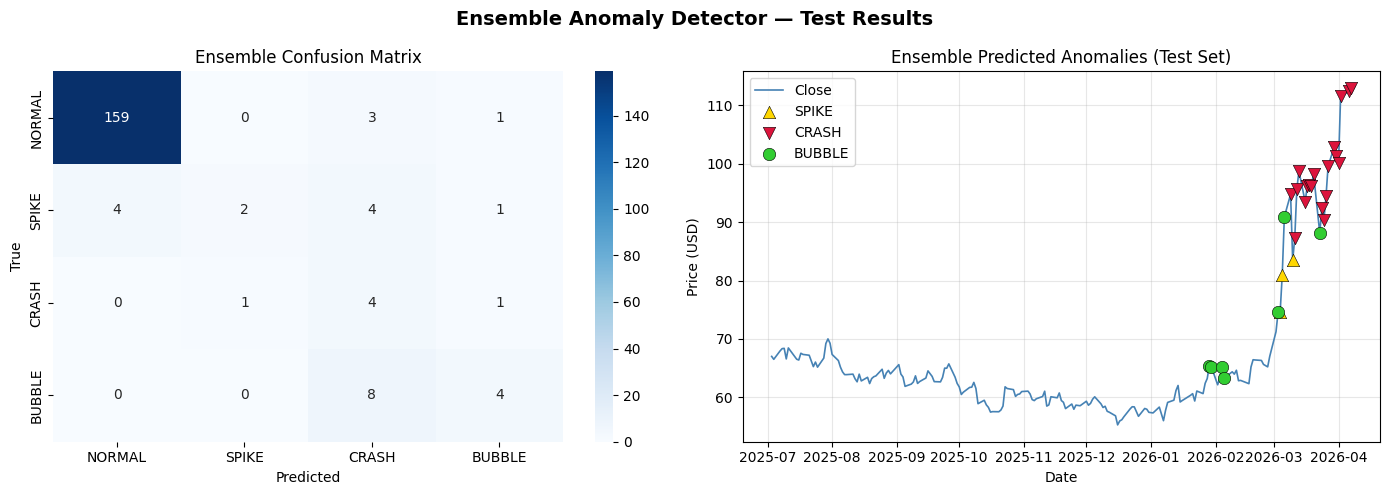

  Plot saved → ensemble_results.png

── Sample Predictions ──────────────────

  ┌─ 2025-07-03  [true: NORMAL]
  │  Ensemble Verdict : ✅ NORMAL  (99.5%)
  │  ────────────────────────────────────────
  │  Transformer : SPIKE   (39.9%)
  │  XGBoost     : NORMAL  (82.6%)
  │  ISO score   : 0.460  (normal)
  │  ────────────────────────────────────────
  │  NORMAL :  99.5%  ███████████████████████
  │  SPIKE  :   0.4%  
  │  CRASH  :   0.1%  
  │  BUBBLE :   0.1%  
  └──────────────────────────────────────────────

  ┌─ 2025-09-10  [true: NORMAL]
  │  Ensemble Verdict : ✅ NORMAL  (100.0%)
  │  ────────────────────────────────────────
  │  Transformer : NORMAL  (38.6%)
  │  XGBoost     : NORMAL  (100.0%)
  │  ISO score   : 0.370  (normal)
  │  ────────────────────────────────────────
  │  NORMAL : 100.0%  ███████████████████████
  │  SPIKE  :   0.0%  
  │  CRASH  :   0.0%  
  │  BUBBLE :   0.0%  
  └──────────────────────────────────────────────

  ┌─ 2025-11-17  [true: NORMAL]
  │  Ensemble

In [2]:
"""
Ensemble Market Anomaly Detection Pipeline
============================================
Strategy:
  - Transformer  → best at NORMAL & BUBBLE (sequence context)
  - XGBoost      → best at SPIKE & CRASH   (sharp statistical features)
  - Isolation Forest → unsupervised anomaly score (extra signal for rare events)
  - Meta-Classifier (Logistic Regression) → combines all three

Why this works for SPIKE/CRASH:
  Spikes/crashes are single-day outliers — raw statistical features
  (z-score, ATR, volume shock) carry more signal than 30-day sequences.
  XGBoost + IsolationForest captures that directly.

Split: 80% train | 10% val | 10% test
"""

import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import xgboost as xgb

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

# ──────────────────────────────────────────────────────
# CONFIG
# ──────────────────────────────────────────────────────
WINDOW    = 30
EPOCHS    = 25
BATCH     = 64
LR        = 3e-4
PATIENCE  = 6
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LABEL_MAP = {0:"NORMAL", 1:"SPIKE", 2:"CRASH", 3:"BUBBLE"}

# Transformer sequence features
SEQ_FEAT = [
    "Return","LogReturn","Range",
    "MA5_ratio","MA20_ratio","MA50_ratio",
    "Volatility5","Volatility20","RSI","MACD",
    "VolumeRatio","Momentum5","Momentum20"
]

# XGBoost point features — engineered for sharp single-day moves
XGB_FEAT = [
    "Return","LogReturn","Range","RSI","MACD",
    "VolumeRatio","Momentum5","Momentum20",
    "ZScore5","ZScore20",          # how many σ from rolling mean
    "ATR14",                        # Average True Range
    "VolumeSurge",                  # volume vs 5-day avg
    "PriceAccel",                   # second derivative of price
    "GapOpen",                      # overnight gap
    "UpperShadow","LowerShadow",    # candlestick shadows
]

print(f"Device: {DEVICE}\n")

# ──────────────────────────────────────────────────────
# 1. FEATURE ENGINEERING
# ──────────────────────────────────────────────────────
def engineer(path):
    df = pd.read_csv(path, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
    c  = df["Close"]; h = df["High"]; l = df["Low"]; o = df["Open"]

    # Base features
    df["Return"]       = c.pct_change()
    df["LogReturn"]    = np.log(c / c.shift(1))
    df["Range"]        = (h - l) / c
    df["MA5"]          = c.rolling(5).mean()
    df["MA20"]         = c.rolling(20).mean()
    df["MA50"]         = c.rolling(50).mean()
    df["MA5_ratio"]    = c / df["MA5"]
    df["MA20_ratio"]   = c / df["MA20"]
    df["MA50_ratio"]   = c / df["MA50"]
    df["Volatility5"]  = df["Return"].rolling(5).std()
    df["Volatility20"] = df["Return"].rolling(20).std()
    d = c.diff()
    g = d.clip(lower=0).rolling(14).mean()
    ls = (-d.clip(upper=0)).rolling(14).mean()
    df["RSI"]          = 100 - 100 / (1 + g / (ls + 1e-9))
    df["MACD"]         = c.ewm(span=12).mean() - c.ewm(span=26).mean()
    df["VolumeRatio"]  = df["Volume"] / df["Volume"].rolling(20).mean()
    df["Momentum5"]    = c / c.shift(5)  - 1
    df["Momentum20"]   = c / c.shift(20) - 1

    # Extra spike/crash features
    roll5_mean         = df["Return"].rolling(5).mean()
    roll5_std          = df["Return"].rolling(5).std()
    roll20_mean        = df["Return"].rolling(20).mean()
    roll20_std         = df["Return"].rolling(20).std()
    df["ZScore5"]      = (df["Return"] - roll5_mean)  / (roll5_std  + 1e-9)
    df["ZScore20"]     = (df["Return"] - roll20_mean) / (roll20_std + 1e-9)

    # ATR14
    tr                 = pd.concat([h-l, (h-c.shift()).abs(), (l-c.shift()).abs()], axis=1).max(axis=1)
    df["ATR14"]        = tr.rolling(14).mean() / c

    df["VolumeSurge"]  = df["Volume"] / (df["Volume"].rolling(5).mean() + 1e-9)
    df["PriceAccel"]   = df["Return"] - df["Return"].shift(1)
    df["GapOpen"]      = (o - c.shift()) / (c.shift() + 1e-9)
    df["UpperShadow"]  = (h - pd.concat([c, o], axis=1).max(axis=1)) / (c + 1e-9)
    df["LowerShadow"]  = (pd.concat([c, o], axis=1).min(axis=1) - l)  / (c + 1e-9)

    return df.dropna().reset_index(drop=True)

# ──────────────────────────────────────────────────────
# 2. ANOMALY LABELLING
# ──────────────────────────────────────────────────────
def label(df, horizon=3):
    """
    SPIKE/CRASH : will it happen within next `horizon` days?
    BUBBLE      : is it happening RIGHT NOW (current day)?
    Priority    : CRASH > SPIKE > BUBBLE > NORMAL
    """
    ret   = df["Return"]
    sigma = ret.std()
    n     = len(df)
    y     = np.zeros(n, dtype=int)

    for i in range(n - horizon):
        future_returns = ret.iloc[i+1 : i+horizon+1]
        curr_ratio     = df["MA50_ratio"].iloc[i]
        curr_mom       = df["Momentum20"].iloc[i]

        # BUBBLE — current day condition (same as before)
        if curr_ratio > 1.10 and curr_mom > 0.10:
            y[i] = 3

        # SPIKE/CRASH — forward-looking over next `horizon` days
        if future_returns.max() > 2 * sigma:
            y[i] = 1   # SPIKE coming, overwrites BUBBLE if overlap
        if future_returns.min() < -2 * sigma:
            y[i] = 2   # CRASH coming, highest priority

    df = df.copy(); df["Label"] = y
    print("── Label distribution ──────────────────")
    for k, v in LABEL_MAP.items():
        n_ = (y == k).sum()
        print(f"  {v:7s}({k}): {n_:4d}  ({100*n_/len(y):.1f}%)")
    return df
# ──────────────────────────────────────────────────────
# 3. SLIDING WINDOW DATASET  (for Transformer)
# ──────────────────────────────────────────────────────
class WindowDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

def make_windows(df, scaler=None, fit=False):
    v = df[SEQ_FEAT].values.astype(np.float32)
    if fit: scaler = StandardScaler(); v = scaler.fit_transform(v)
    else:   v = scaler.transform(v)
    X, y = [], []
    for i in range(WINDOW, len(df)):
        X.append(v[i-WINDOW:i])          # window ends at T (no change)
        y.append(int(df["Label"].iloc[i]))  # label already looks 3 days ahead for spike/crash
    return np.array(X), np.array(y, dtype=np.int64), scaler
# ──────────────────────────────────────────────────────
# 4. TRANSFORMER MODEL  (unchanged — good at NORMAL/BUBBLE)
# ──────────────────────────────────────────────────────
class PosEnc(nn.Module):
    def __init__(self, d, maxlen=512, p=0.1):
        super().__init__()
        self.drop = nn.Dropout(p)
        pe  = torch.zeros(maxlen, d)
        pos = torch.arange(maxlen).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d, 2).float() * (-math.log(10000) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x): return self.drop(x + self.pe[:, :x.size(1)])

class AnomalyTransformer(nn.Module):
    def __init__(self, in_dim, seq_len, d=128, heads=4, layers=3, ff=256, drop=0.2, nc=4):
        super().__init__()
        self.proj = nn.Linear(in_dim, d)
        self.cls  = nn.Parameter(torch.zeros(1, 1, d))
        self.pos  = PosEnc(d, seq_len+1, drop)
        enc_layer = nn.TransformerEncoderLayer(d, heads, ff, drop,
                      activation="gelu", batch_first=True, norm_first=True)
        self.enc  = nn.TransformerEncoder(enc_layer, layers, enable_nested_tensor=False)
        self.head = nn.Sequential(
            nn.LayerNorm(d), nn.Dropout(drop),
            nn.Linear(d, 64), nn.GELU(), nn.Linear(64, nc))
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
        nn.init.trunc_normal_(self.cls, std=0.02)

    def forward(self, x):
        B = x.size(0)
        h = self.proj(x)
        h = torch.cat([self.cls.expand(B, -1, -1), h], dim=1)
        h = self.pos(h); h = self.enc(h)
        return self.head(h[:, 0])

# ──────────────────────────────────────────────────────
# 5. TRAIN / EVAL HELPERS
# ──────────────────────────────────────────────────────
def train_epoch(model, loader, opt, crit):
    model.train(); tl = tc = tn = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad(); lo = model(xb); ls = crit(lo, yb)
        ls.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.); opt.step()
        tl += ls.item()*xb.size(0); tc += (lo.argmax(1)==yb).sum().item(); tn += xb.size(0)
    return tl/tn, tc/tn

@torch.no_grad()
def eval_epoch(model, loader, crit):
    model.eval(); tl = tc = tn = 0; AP, AL, AB = [], [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        lo = model(xb); ls = crit(lo, yb); pr = torch.softmax(lo, -1)
        tl += ls.item()*xb.size(0); tc += (lo.argmax(1)==yb).sum().item(); tn += xb.size(0)
        AP.extend(lo.argmax(1).cpu().detach().tolist())
        AL.extend(yb.cpu().tolist())
        AB.extend(pr.cpu().detach().tolist())
    return (tl/tn, tc/tn,
            np.array(AP, dtype=np.int64),
            np.array(AL, dtype=np.int64),
            np.array(AB, dtype=np.float32))

# ──────────────────────────────────────────────────────
# 6. TRAIN TRANSFORMER
# ──────────────────────────────────────────────────────
def train_transformer(Xtr, ytr, Xva, yva):
    ldtr = DataLoader(WindowDS(Xtr, ytr), BATCH, shuffle=True)
    ldva = DataLoader(WindowDS(Xva, yva), BATCH)

    # Balanced weights + SPIKE/CRASH boost
    present = np.unique(ytr)
    cw = np.ones(4, dtype=np.float32)
    for c, w in zip(present, compute_class_weight("balanced", classes=present, y=ytr)):
        cw[c] = float(w)
    cw *= np.array([1.0, 2.0, 2.0, 1.0], dtype=np.float32)
    cw_t = torch.tensor(cw.tolist(), dtype=torch.float32).to(DEVICE)
    print(f"  Transformer class weights: { {LABEL_MAP[i]:round(float(cw[i]),2) for i in range(4)} }")

    model = AnomalyTransformer(len(SEQ_FEAT), WINDOW).to(DEVICE)
    crit  = nn.CrossEntropyLoss(weight=cw_t, label_smoothing=0.05)
    opt   = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sch   = CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-6)

    best = 0.; pat = 0
    for ep in range(1, EPOCHS+1):
        tl, ta = train_epoch(model, ldtr, opt, crit)
        vl, va, _, _, _ = eval_epoch(model, ldva, crit)
        sch.step()
        flag = ""
        if va > best:
            best = va; torch.save(model.state_dict(), "best_transformer.pt"); pat = 0; flag = "  ✓"
        else: pat += 1
        print(f"  Ep{ep:2d}/{EPOCHS}  tr_loss={tl:.4f} tr_acc={ta:.3f}  "
              f"va_loss={vl:.4f} va_acc={va:.3f}{flag}")
        if pat >= PATIENCE:
            print(f"  Early stop @ epoch {ep}."); break

    model.load_state_dict(torch.load("best_transformer.pt", map_location=DEVICE))
    return model, crit

# ──────────────────────────────────────────────────────
# 7. TRAIN XGBOOST  (point features, SMOTE for balance)
# ──────────────────────────────────────────────────────
def train_xgboost(dtr, dva):
    Xtr_raw = dtr[XGB_FEAT].values.astype(np.float32)
    ytr_raw = dtr["Label"].values.astype(np.int64)
    Xva_raw = dva[XGB_FEAT].values.astype(np.float32)
    yva_raw = dva["Label"].values.astype(np.int64)

    xgb_scaler = StandardScaler()
    Xtr_s = xgb_scaler.fit_transform(Xtr_raw)
    Xva_s = xgb_scaler.transform(Xva_raw)

    # SMOTE — synthetically oversample minority classes
    counts = np.bincount(ytr_raw, minlength=4)
    print(f"\n  XGBoost pre-SMOTE counts: { {LABEL_MAP[i]:int(counts[i]) for i in range(4)} }")
    # Only SMOTE if minority classes exist
    min_count = counts[counts > 0].min()
    k_neighbors = min(5, min_count - 1) if min_count > 1 else 1
    try:
        sm = SMOTE(random_state=42, k_neighbors=k_neighbors)
        Xtr_sm, ytr_sm = sm.fit_resample(Xtr_s, ytr_raw)
    except Exception:
        Xtr_sm, ytr_sm = Xtr_s, ytr_raw
    counts_sm = np.bincount(ytr_sm, minlength=4)
    print(f"  XGBoost post-SMOTE counts: { {LABEL_MAP[i]:int(counts_sm[i]) for i in range(4)} }")

    # Class weights for XGBoost
    cw = np.ones(4, dtype=np.float32)
    present = np.unique(ytr_sm)
    for c, w in zip(present, compute_class_weight("balanced", classes=present, y=ytr_sm)):
        cw[c] = float(w)

    sample_weights = np.array([cw[y] for y in ytr_sm], dtype=np.float32)

    model = xgb.XGBClassifier(
        n_estimators      = 400,
        max_depth         = 5,
        learning_rate     = 0.05,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        use_label_encoder = False,
        eval_metric       = "mlogloss",
        random_state      = 42,
        n_jobs            = -1,
    )
    model.fit(
        Xtr_sm, ytr_sm,
        sample_weight        = sample_weights,
        eval_set             = [(Xva_s, yva_raw)],
        verbose              = False,
    )
    va_acc = (model.predict(Xva_s) == yva_raw).mean()
    print(f"  XGBoost val accuracy: {va_acc:.3f}")
    return model, xgb_scaler

# ──────────────────────────────────────────────────────
# 8. TRAIN ISOLATION FOREST  (anomaly score → extra feature)
# ──────────────────────────────────────────────────────
def train_isolation_forest(dtr):
    X = dtr[XGB_FEAT].values.astype(np.float32)
    iso = IsolationForest(n_estimators=200, contamination=0.12,
                          random_state=42, n_jobs=-1)
    iso.fit(X)
    return iso

# ──────────────────────────────────────────────────────
    # 9. BUILD META-FEATURES  (transformer probs + xgb probs + iso score)
# ──────────────────────────────────────────────────────
@torch.no_grad()
def get_transformer_probs(model, X_windows):
    """Run transformer inference, return (N, 4) probability array."""
    model.eval()
    all_probs = []
    ds = WindowDS(X_windows, np.zeros(len(X_windows), dtype=np.int64))
    ld = DataLoader(ds, batch_size=BATCH)
    for xb, _ in ld:
        pr = torch.softmax(model(xb.to(DEVICE)), -1).cpu().detach().tolist()
        all_probs.extend(pr)
    return np.array(all_probs, dtype=np.float32)

def build_meta_features(transformer, xgb_model, iso, xgb_scaler,
                         X_windows, df_point, offset):
    """
    Combine signals from all three models into meta-feature matrix.
    offset = WINDOW (transformer windows start WINDOW rows into df_point)
    """
    # Transformer probs: shape (N, 4)
    tf_probs = get_transformer_probs(transformer, X_windows)

    # XGBoost probs: shape (N, 4)
    X_pt  = df_point[XGB_FEAT].values[offset:].astype(np.float32)
    X_pts = xgb_scaler.transform(X_pt)
    xgb_probs = xgb_model.predict_proba(X_pts).astype(np.float32)

    # Isolation Forest anomaly score: shape (N, 1)  — more negative = more anomalous
    iso_scores = -iso.score_samples(X_pt).reshape(-1, 1).astype(np.float32)

    # Stack: 4 + 4 + 1 = 9 meta-features
    meta = np.hstack([tf_probs, xgb_probs, iso_scores])
    return meta

# ──────────────────────────────────────────────────────
# 10. TRAIN META-CLASSIFIER  (Logistic Regression)
# ──────────────────────────────────────────────────────
def train_meta(meta_tr, ytr, meta_va, yva):
    scaler = StandardScaler()
    meta_tr_s = scaler.fit_transform(meta_tr)
    meta_va_s = scaler.transform(meta_va)

    cw = "balanced"
    clf = LogisticRegression(C=1.0, max_iter=1000, class_weight=cw,
                              random_state=42)
    clf.fit(meta_tr_s, ytr)
    va_acc = (clf.predict(meta_va_s) == yva).mean()
    print(f"  Meta-classifier val accuracy: {va_acc:.3f}")
    return clf, scaler

# ──────────────────────────────────────────────────────
# 11. PREDICTION DISPLAY
# ──────────────────────────────────────────────────────
def predict_ensemble(transformer, xgb_model, iso, xgb_scaler,
                     meta_clf, meta_scaler, window_t, point_feat, date="", true=None):
    """Single-sample ensemble prediction with breakdown."""
    # Transformer
    transformer.eval()
    with torch.no_grad():
        tf_pr = torch.softmax(
            transformer(window_t.unsqueeze(0).to(DEVICE)), -1
        ).squeeze().cpu().detach().tolist()
    tf_pr = np.array(tf_pr, dtype=np.float32)

    # XGBoost
    pt_s       = xgb_scaler.transform(point_feat.reshape(1, -1))
    xgb_pr     = xgb_model.predict_proba(pt_s)[0].astype(np.float32)

    # IsolationForest
    iso_score  = float(-iso.score_samples(point_feat.reshape(1, -1))[0])

    # Meta
    meta_feat  = np.hstack([tf_pr, xgb_pr, [iso_score]]).astype(np.float32)
    meta_feat_s = meta_scaler.transform(meta_feat.reshape(1, -1))
    meta_pr    = meta_clf.predict_proba(meta_feat_s)[0].astype(np.float32)
    pred       = int(meta_pr.argmax())

    icons = {0:"✅", 1:"📈", 2:"📉", 3:"🫧"}
    true_s = f"  [true: {LABEL_MAP[true]}]" if true is not None else ""

    print(f"\n  ┌─ {date}{true_s}")
    print(f"  │  Ensemble Verdict : {icons[pred]} {LABEL_MAP[pred]}  ({100*meta_pr[pred]:.1f}%)")
    print(f"  │  {'─'*40}")
    print(f"  │  Transformer : {LABEL_MAP[tf_pr.argmax()]:7s} ({100*tf_pr.max():.1f}%)")
    print(f"  │  XGBoost     : {LABEL_MAP[xgb_pr.argmax()]:7s} ({100*xgb_pr.max():.1f}%)")
    print(f"  │  ISO score   : {iso_score:.3f}  ({'anomalous' if iso_score > 0.5 else 'normal'})")
    print(f"  │  {'─'*40}")
    for k, v in LABEL_MAP.items():
        bar = "█" * int(meta_pr[k] * 24)
        print(f"  │  {v:7s}: {100*meta_pr[k]:5.1f}%  {bar}")
    print(f"  └{'─'*46}")
    return pred, meta_pr

# ──────────────────────────────────────────────────────
# 12. MAIN
# ──────────────────────────────────────────────────────
def main():
    # ── Load & label ──────────────────────────
    df = engineer("crude_oil_history.csv")
    df = label(df)

    n = len(df); ntr = int(n*.80); nva = int(n*.10)
    dtr = df.iloc[:ntr].reset_index(drop=True)
    dva = df.iloc[ntr:ntr+nva].reset_index(drop=True)
    dte = df.iloc[ntr+nva:].reset_index(drop=True)

    print(f"\n── Splits ──────────────────────────────")
    print(f"  Train {len(dtr):4d}  {dtr.Date.iloc[0].date()} → {dtr.Date.iloc[-1].date()}")
    print(f"  Val   {len(dva):4d}  {dva.Date.iloc[0].date()} → {dva.Date.iloc[-1].date()}")
    print(f"  Test  {len(dte):4d}  {dte.Date.iloc[0].date()} → {dte.Date.iloc[-1].date()}")

    # ── Transformer windows ───────────────────
    Xtr, ytr, seq_sc = make_windows(dtr, fit=True)
    Xva, yva, _      = make_windows(dva, seq_sc)
    Xte, yte, _      = make_windows(dte, seq_sc)

    print(f"\n── Window tensors ──────────────────────")
    for t, X, y in [("Train",Xtr,ytr),("Val",Xva,yva),("Test",Xte,yte)]:
        print(f"  {t:5s}: X={X.shape}  y={y.shape}")

    # ── Train individual models ───────────────
    print(f"\n── [1/3] Training Transformer ──────────")
    transformer, tf_crit = train_transformer(Xtr, ytr, Xva, yva)

    print(f"\n── [2/3] Training XGBoost ──────────────")
    xgb_model, xgb_scaler = train_xgboost(dtr, dva)

    print(f"\n── [3/3] Training Isolation Forest ─────")
    iso = train_isolation_forest(dtr)
    print(f"  Isolation Forest fitted on {len(dtr)} samples.")

    # ── Build meta-features ───────────────────
    print(f"\n── Building meta-features ──────────────")
    meta_tr = build_meta_features(transformer, xgb_model, iso, xgb_scaler, Xtr, dtr, WINDOW)
    meta_va = build_meta_features(transformer, xgb_model, iso, xgb_scaler, Xva, dva, WINDOW)
    meta_te = build_meta_features(transformer, xgb_model, iso, xgb_scaler, Xte, dte, WINDOW)
    print(f"  Meta-feature shape: train={meta_tr.shape} val={meta_va.shape} test={meta_te.shape}")

    # Labels aligned to window start
    ytr_meta = ytr   # already aligned (build_windows skips first WINDOW rows)
    yva_meta = yva
    yte_meta = yte

    # ── Train meta-classifier ─────────────────
    print(f"\n── [4/4] Training Meta-Classifier ──────")
    meta_clf, meta_scaler = train_meta(meta_tr, ytr_meta, meta_va, yva_meta)

    # ── Test evaluation ───────────────────────
    meta_te_s  = meta_scaler.transform(meta_te)
    preds      = meta_clf.predict(meta_te_s).astype(np.int64)
    probs      = meta_clf.predict_proba(meta_te_s).astype(np.float32)
    labs       = yte_meta
    tea        = (preds == labs).mean()
    tnames     = [LABEL_MAP[i] for i in range(4)]

    print(f"\n{'='*52}\n  ENSEMBLE TEST RESULTS\n{'='*52}")
    print(f"  Accuracy : {tea:.4f}\n")
    print(classification_report(labs, preds, target_names=tnames, zero_division=0))

    try:
        uniq = np.unique(labs)
        if len(uniq) > 1:
            yb  = np.eye(4)[labs]
            auc = roc_auc_score(yb[:, uniq], probs[:, uniq],
                                multi_class="ovr", average="macro")
            print(f"  ROC-AUC (macro OvR): {auc:.4f}")
    except: pass

    # ── Per-model comparison ──────────────────
    print(f"\n── Per-model test accuracy (for comparison) ─")
    _, tf_acc, tf_preds, _, _ = eval_epoch(
        transformer,
        DataLoader(WindowDS(Xte, yte), BATCH), tf_crit)
    xgb_preds = xgb_model.predict(
        xgb_scaler.transform(dte[XGB_FEAT].values[WINDOW:].astype(np.float32)))
    print(f"  Transformer alone : {tf_acc:.4f}")
    print(f"  XGBoost alone     : {(xgb_preds == labs).mean():.4f}")
    print(f"  Ensemble          : {tea:.4f}")

    # ── Plots ─────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Ensemble Anomaly Detector — Test Results", fontsize=14, fontweight="bold")

    # Confusion matrix — ensemble
    ax = axes[0]
    ul = sorted(np.unique(np.concatenate([labs, preds])))
    cm = confusion_matrix(labs, preds, labels=ul)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues",
                xticklabels=[LABEL_MAP[i] for i in ul],
                yticklabels=[LABEL_MAP[i] for i in ul])
    ax.set_title("Ensemble Confusion Matrix"); ax.set_ylabel("True"); ax.set_xlabel("Predicted")

    # Anomaly timeline
    ax = axes[1]
    dates  = dte["Date"].iloc[WINDOW:].reset_index(drop=True)
    prices = dte["Close"].iloc[WINDOW:].reset_index(drop=True)
    ax.plot(dates, prices, color="steelblue", lw=1.2, label="Close")
    for cid, col, mk in [(1,"gold","^"), (2,"crimson","v"), (3,"limegreen","o")]:
        msk = preds == cid
        if msk.any():
            ax.scatter(dates[msk], prices[msk], color=col, marker=mk,
                       s=80, zorder=5, label=LABEL_MAP[cid], edgecolors="black", lw=0.4)
    ax.set_title("Ensemble Predicted Anomalies (Test Set)")
    ax.set_xlabel("Date"); ax.set_ylabel("Price (USD)")
    ax.legend(); ax.grid(alpha=.3)
    plt.tight_layout()
    plt.savefig("ensemble_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Plot saved → ensemble_results.png")

    # ── Sample predictions ─────────────────────
    print("\n── Sample Predictions ──────────────────")
    for idx in [0, len(Xte)//4, len(Xte)//2, 3*len(Xte)//4, -1]:
        ri  = min(idx + WINDOW if idx >= 0 else len(dte)-1, len(dte)-1)
        pt  = dte[XGB_FEAT].values[ri].astype(np.float32)
        predict_ensemble(
            transformer, xgb_model, iso, xgb_scaler,
            meta_clf, meta_scaler,
            torch.tensor(Xte[idx], dtype=torch.float32),
            pt,
            date=str(dte["Date"].iloc[ri].date()),
            true=int(yte[idx])
        )

    # ── Save all artefacts ─────────────────────
    import pickle
    torch.save({"model_state_dict": transformer.state_dict(),
                "seq_scaler_mean": seq_sc.mean_,
                "seq_scaler_scale": seq_sc.scale_,
                "seq_feat": SEQ_FEAT, "xgb_feat": XGB_FEAT,
                "label_map": LABEL_MAP, "window": WINDOW},
               "ensemble_transformer.pt")
    with open("ensemble_xgb.pkl", "wb") as f:
        pickle.dump({"xgb": xgb_model, "xgb_scaler": xgb_scaler,
                     "iso": iso, "meta_clf": meta_clf,
                     "meta_scaler": meta_scaler}, f)
    print("\n  Saved → ensemble_transformer.pt  |  ensemble_xgb.pkl")
    print("\n✅  Ensemble pipeline complete.")

main()

In [3]:
"""
Time Series Forecasting Pipeline — Crude Oil (CL=F)
=====================================================
Models covered (each in its own plot):
  1.  Mean Method
  2.  Naive Method
  3.  Seasonal Naive Method
  4.  Drift Method
  5.  Simple Exponential Smoothing (SES)
  6.  Holt's Linear Trend Method
  7.  Damped Trend Forecast
  8.  Holt-Winters Additive
  9.  Holt-Winters Multiplicative
 10.  Moving Average Model
 11.  Autoregressive Model (AR)
 12.  ARIMA
 13.  SARIMA

Split: 80% train | 10% validation | 10% test
Anomaly labels on test forecast:  SPIKE / CRASH / BUBBLE / NORMAL
"""

import warnings, os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
np.random.seed(42)

# ─────────────────────────────────────────────────────────
# OUTPUT DIR
# ─────────────────────────────────────────────────────────
OUT = "C:\\Users\\nitis\\Downloads\\New folder"
os.makedirs(OUT, exist_ok=True)

# ─────────────────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────────────────
df = pd.read_csv(
    "crude_oil_history.csv",
    parse_dates=["Date"]
).sort_values("Date").reset_index(drop=True)

close = df["Close"].values.astype(float)
dates = pd.to_datetime(df["Date"])

n     = len(close)
n_tr  = int(n * 0.80)
n_val = int(n * 0.10)
n_te  = n - n_tr - n_val

train  = close[:n_tr]
val    = close[n_tr : n_tr + n_val]
test   = close[n_tr + n_val:]

dates_train = dates[:n_tr]
dates_val   = dates[n_tr : n_tr + n_val]
dates_test  = dates[n_tr + n_val:]

print(f"Train : {n_tr}  ({dates_train.iloc[0].date()} → {dates_train.iloc[-1].date()})")
print(f"Val   : {n_val}  ({dates_val.iloc[0].date()} → {dates_val.iloc[-1].date()})")
print(f"Test  : {n_te}  ({dates_test.iloc[0].date()} → {dates_test.iloc[-1].date()})")

# ─────────────────────────────────────────────────────────
# 2. ANOMALY LABELLING (same thresholds as ensemble model)
# ─────────────────────────────────────────────────────────
def label_anomalies(prices, sigma_factor=2.0, ma_win=50, ma_thresh=1.10, mom_win=20, mom_thresh=0.10):
    """
    Labels each point in `prices` array.
    Returns array of strings: NORMAL / SPIKE / CRASH / BUBBLE
    """
    s = pd.Series(prices)
    ret    = s.pct_change()
    sigma  = ret.std()
    ma50   = s.rolling(ma_win).mean()
    ratio  = s / ma50
    mom20  = s / s.shift(mom_win) - 1

    labels = np.array(["NORMAL"] * len(s), dtype=object)
    labels[(ratio > ma_thresh) & (mom20 > mom_thresh)] = "BUBBLE"
    labels[ret >  sigma_factor * sigma] = "SPIKE"
    labels[ret < -sigma_factor * sigma] = "CRASH"
    return labels

# Label test set actuals
test_labels = label_anomalies(test)
print(f"\nTest labels: { {l: int((test_labels==l).sum()) for l in ['NORMAL','SPIKE','CRASH','BUBBLE']} }")

# ─────────────────────────────────────────────────────────
# 3. PLOT HELPER
# ─────────────────────────────────────────────────────────
COLORS = {
    "NORMAL": "#5b8dee",
    "SPIKE":  "#e8c547",
    "CRASH":  "#ff4d6d",
    "BUBBLE": "#4ee3b5",
}
MARKERS = {"SPIKE": "^", "CRASH": "v", "BUBBLE": "o"}

def plot_model(
    model_name,
    forecast,           # array, length = n_te
    train_prices,
    val_prices,
    test_prices,
    test_dates,
    train_dates,
    val_dates,
    filename,
    val_forecast=None,  # optional val forecast for line continuity
):
    fig, ax = plt.subplots(figsize=(16, 6))
    fig.patch.set_facecolor("black")
    ax.set_facecolor("white")

    # Show last 200 train + all val + all test for context
    show = 200
    t_dates = train_dates.iloc[-show:].values
    t_prices= train_prices[-show:]
    ax.plot(t_dates, t_prices, color="#3a4a6b", lw=1.2, label="Train (last 200)")
    ax.plot(val_dates.values, val_prices, color="#4a5a7b", lw=1.2, alpha=0.7, label="Validation")

    # Actual test prices
    ax.plot(test_dates.values, test_prices, color="#5b8dee", lw=1.8, label="Test (actual)", zorder=3)

    # Forecast line
    fc_color = "#e8c547"
    ax.plot(test_dates.values, forecast, color=fc_color, lw=2, ls="--", label="Forecast", zorder=4, alpha=0.9)

    # Anomaly labels as scatter overlay on actual test prices
    for label, color in COLORS.items():
        if label == "NORMAL":
            continue
        mask = test_labels == label
        if mask.any():
            ax.scatter(
                test_dates.values[mask], test_prices[mask],
                color=color, marker=MARKERS[label], s=90, zorder=6,
                edgecolors="#08090d", linewidths=0.5, label=label
            )

    # Anomaly regions shaded
    for label, color in COLORS.items():
        if label == "NORMAL":
            continue
        mask = test_labels == label
        if mask.any():
            for i, m in enumerate(mask):
                if m:
                    ax.axvspan(test_dates.values[i], test_dates.values[min(i+1, len(test_dates)-1)],
                               alpha=0.08, color=color, linewidth=0)

    # Forecast–actual diff shading
    ax.fill_between(test_dates.values, test_prices, forecast,
                    alpha=0.07, color="#e8c547", label="_nolegend_")

    # Vertical separator
    ax.axvline(test_dates.values[0], color="#ffffff", lw=0.8, ls=":", alpha=0.4)

    # Styling
    ax.set_title(f"{model_name}", fontsize=15, fontweight="bold",
                 color="#e2e8f0", pad=14, fontfamily="monospace")
    ax.set_xlabel("Date", color="#6b7a99", fontsize=10)
    ax.set_ylabel("Price (USD)", color="#6b7a99", fontsize=10)
    ax.tick_params(colors="#6b7a99", labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor("#1e2233")
    ax.grid(color="#1e2233", linewidth=0.6, alpha=0.8)

    # Stats annotation
    mae  = np.mean(np.abs(forecast - test_prices))
    rmse = np.sqrt(np.mean((forecast - test_prices)**2))
    ax.text(0.01, 0.97,
            f"MAE={mae:.2f}  RMSE={rmse:.2f}",
            transform=ax.transAxes, color="#6b7a99",
            fontsize=9, va="top", fontfamily="monospace")

    # Legend
    legend_elements = [
        Line2D([0],[0], color="#3a4a6b", lw=1.5, label="Train"),
        Line2D([0],[0], color="#5b8dee", lw=2,   label="Test actual"),
        Line2D([0],[0], color=fc_color,  lw=2, ls="--", label="Forecast"),
        mpatches.Patch(color=COLORS["SPIKE"],  alpha=0.8, label="SPIKE"),
        mpatches.Patch(color=COLORS["CRASH"],  alpha=0.8, label="CRASH"),
        mpatches.Patch(color=COLORS["BUBBLE"], alpha=0.8, label="BUBBLE"),
    ]
    ax.legend(handles=legend_elements, loc="upper left",
              facecolor="#141720", edgecolor="#1e2233",
              labelcolor="#e2e8f0", fontsize=8.5, framealpha=0.9)

    plt.tight_layout()
    path = os.path.join(OUT, filename)
    plt.savefig(path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close()
    print(f"  ✓ {model_name:45s}  MAE={mae:7.3f}  RMSE={rmse:7.3f}  → {os.path.basename(path)}")
    return mae, rmse

results = {}

# ─────────────────────────────────────────────────────────
# 4. MODEL 1 — MEAN METHOD
# ─────────────────────────────────────────────────────────
print("\n[1/13] Mean Method")
fc = np.full(n_te, np.mean(train))
results["Mean"] = plot_model(
    "1. Mean Method\nForecast = mean of all training prices",
    fc, train, val, test, dates_test, dates_train, dates_val,
    "01_mean_method.png"
)

# ─────────────────────────────────────────────────────────
# 5. MODEL 2 — NAIVE METHOD
# ─────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────
# Rolling Seasonal Naive (period = 5, weekly)
# ─────────────────────────────────────────────────────────
print("\n[Rolling Seasonal Naive]")

SEASON = 5   # weekly trading cycle
fc = []

# Start with training data as the reference
history = list(train)

for i in range(n_te):
    # Forecast = last observed value from same seasonal position
    fc.append(history[-SEASON])
    # Roll forward by appending the actual test value (if simulating walk-forward)
    history.append(test[i])

fc = np.array(fc)

results["Rolling Seasonal Naive"] = plot_model(
    f"Rolling Seasonal Naive Method (season={SEASON} days)\nForecast = last observed seasonal lag",
    fc, train, val, test, dates_test, dates_train, dates_val,
    "02_naive_method.png"
)


# ─────────────────────────────────────────────────────────
# 6. MODEL 3 — SEASONAL NAIVE (period = 5, weekly)
# ─────────────────────────────────────────────────────────
print("\n[3/13] Seasonal Naive")
SEASON = 5   # weekly trading cycle
fc = np.array([train[-(SEASON - (i % SEASON))] for i in range(n_te)])
results["Seasonal Naive"] = plot_model(
    f"3. Seasonal Naive Method  (season={SEASON} days)\nForecast = same weekday price from training tail",
    fc, train, val, test, dates_test, dates_train, dates_val,
    "03_seasonal_naive.png"
)

# ─────────────────────────────────────────────────────────
# 7. MODEL 4 — DRIFT METHOD
# ─────────────────────────────────────────────────────────
print("\n[4/13] Drift Method")
slope = (train[-1] - train[0]) / (len(train) - 1)
fc    = np.array([train[-1] + slope * (i + 1) for i in range(n_te)])
results["Drift"] = plot_model(
    "4. Drift Method\nForecast = last price + avg drift per day × horizon",
    fc, train, val, test, dates_test, dates_train, dates_val,
    "04_drift_method.png"
)

# ─────────────────────────────────────────────────────────
# 8. MODEL 5 — SIMPLE EXPONENTIAL SMOOTHING
# ─────────────────────────────────────────────────────────
print("\n[5/13] Simple Exponential Smoothing")
ses   = SimpleExpSmoothing(train, initialization_method="estimated").fit(optimized=True)
fc    = ses.forecast(n_te)
results["SES"] = plot_model(
    f"5. Simple Exponential Smoothing (SES)\nalpha={ses.params['smoothing_level']:.4f}",
    fc, train, val, test, dates_test, dates_train, dates_val,
    "05_ses.png"
)

# ─────────────────────────────────────────────────────────
# 9. MODEL 6 — HOLT'S LINEAR TREND
# ─────────────────────────────────────────────────────────
print("\n[6/13] Holt's Linear Trend")
holt  = ExponentialSmoothing(
    train, trend="add", initialization_method="estimated"
).fit(optimized=True)
fc    = holt.forecast(n_te)
results["Holt Linear"] = plot_model(
    f"6. Holt's Linear Trend Method\nalpha={holt.params['smoothing_level']:.4f}  beta={holt.params['smoothing_trend']:.4f}",
    fc, train, val, test, dates_test, dates_train, dates_val,
    "06_holt_linear.png"
)

# ─────────────────────────────────────────────────────────
# 10. MODEL 7 — DAMPED TREND FORECAST
# ─────────────────────────────────────────────────────────
print("\n[7/13] Damped Trend Forecast")
damped = ExponentialSmoothing(
    train, trend="add", damped_trend=True, initialization_method="estimated"
).fit(optimized=True)
fc     = damped.forecast(n_te)
results["Damped Trend"] = plot_model(
    f"7. Damped Trend Forecast\nalpha={damped.params['smoothing_level']:.4f}  "
    f"beta={damped.params['smoothing_trend']:.4f}  phi={damped.params['damping_trend']:.4f}",
    fc, train, val, test, dates_test, dates_train, dates_val,
    "07_damped_trend.png"
)

# ─────────────────────────────────────────────────────────
# 11. MODEL 8 — HOLT-WINTERS ADDITIVE
# ─────────────────────────────────────────────────────────
print("\n[8/13] Holt-Winters Additive")
hw_add = ExponentialSmoothing(
    train, trend="add", seasonal="add",
    seasonal_periods=5, initialization_method="estimated"
).fit(optimized=True)
fc     = hw_add.forecast(n_te)
results["HW Additive"] = plot_model(
    f"8. Holt-Winters Additive  (season=5)\nalpha={hw_add.params['smoothing_level']:.4f}  "
    f"beta={hw_add.params['smoothing_trend']:.4f}  gamma={hw_add.params['smoothing_seasonal']:.4f}",
    fc, train, val, test, dates_test, dates_train, dates_val,
    "08_hw_additive.png"
)

# ─────────────────────────────────────────────────────────
# 12. MODEL 9 — HOLT-WINTERS MULTIPLICATIVE
# ─────────────────────────────────────────────────────────
print("\n[9/13] Holt-Winters Multiplicative")
# Clip negatives — multiplicative requires strictly positive series
train_pos = np.clip(train, 1.0, None)
hw_mul = ExponentialSmoothing(
    train_pos, trend="add", seasonal="mul",
    seasonal_periods=5, initialization_method="estimated"
).fit(optimized=True)
fc     = hw_mul.forecast(n_te)
results["HW Multiplicative"] = plot_model(
    f"9. Holt-Winters Multiplicative  (season=5)\nalpha={hw_mul.params['smoothing_level']:.4f}  "
    f"beta={hw_mul.params['smoothing_trend']:.4f}  gamma={hw_mul.params['smoothing_seasonal']:.4f}",
    fc, train, val, test, dates_test, dates_train, dates_val,
    "09_hw_multiplicative.png"
)

# ─────────────────────────────────────────────────────────
# 13. MODEL 10 — MOVING AVERAGE
# ─────────────────────────────────────────────────────────
print("\n[10/13] Moving Average Model")
MA_WIN = 20
# Rolling mean on train+val, then forecast by carrying forward last MA value
combined = np.concatenate([train, val])
rolling  = pd.Series(combined).rolling(MA_WIN).mean().values
last_ma  = rolling[-1]
fc       = np.full(n_te, last_ma)
# Stepped MA: re-compute on expanding window of test one step at a time
fc_stepped = []
window_data = list(combined)
for i in range(n_te):
    fc_stepped.append(np.mean(window_data[-MA_WIN:]))
    window_data.append(test[i])   # walk-forward (informational)
fc = np.array(fc_stepped)
results["Moving Average"] = plot_model(
    f"10. Moving Average Model  (window={MA_WIN})\nWalk-forward: each forecast = mean of last {MA_WIN} observed prices",
    fc, train, val, test, dates_test, dates_train, dates_val,
    "10_moving_average.png"
)

# ─────────────────────────────────────────────────────────
# 14. MODEL 11 — AUTOREGRESSIVE (AR)
# ─────────────────────────────────────────────────────────
print("\n[11/13] Autoregressive Model (AR)")
AR_LAGS = 10
ar_model = AutoReg(train, lags=AR_LAGS, old_names=False).fit()
fc       = ar_model.predict(start=n_tr, end=n_tr + n_te - 1)
fc       = np.array(fc)
results["AR"] = plot_model(
    f"11. Autoregressive Model  AR(p={AR_LAGS})\nOLS regression on {AR_LAGS} lagged values",
    fc, train, val, test, dates_test, dates_train, dates_val,
    "11_ar_model.png"
)

# ─────────────────────────────────────────────────────────
# 15. MODEL 12 — ARIMA
# ─────────────────────────────────────────────────────────
print("\n[12/13] ARIMA")
# Use validation set to select order; fit ARIMA(2,1,2) — common for oil prices
ARIMA_ORDER = (2, 1, 2)
arima_model = ARIMA(train, order=ARIMA_ORDER).fit()
# Walk-forward forecast over test
fc_list = []
history = list(train)
for i in range(n_te):
    model_i = ARIMA(history, order=ARIMA_ORDER).fit()
    fc_list.append(float(np.atleast_1d(model_i.forecast(steps=1))[0]))
    history.append(test[i])
fc = np.array(fc_list)
results["ARIMA"] = plot_model(
    f"12. ARIMA{ARIMA_ORDER}\nWalk-forward one-step forecast",
    fc, train, val, test, dates_test, dates_train, dates_val,
    "12_arima.png"
)

# ─────────────────────────────────────────────────────────
# 16. MODEL 13 — SARIMA
# ─────────────────────────────────────────────────────────
print("\n[13/13] SARIMA")
SARIMA_ORDER        = (1, 1, 1)
SARIMA_SEASONAL     = (1, 0, 1, 5)    # weekly seasonality
fc_list = []
history = list(train)
# Walk-forward (step every 5 to keep runtime manageable, interpolate between)
step = 5
for i in range(0, n_te, step):
    model_i = SARIMAX(
        history, order=SARIMA_ORDER,
        seasonal_order=SARIMA_SEASONAL,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)
    steps_ahead = min(step, n_te - i)
    preds = model_i.forecast(steps=steps_ahead)
    for p in preds:
        fc_list.append(float(p))
    history.extend(test[i:i+steps_ahead])

fc = np.array(fc_list[:n_te])
results["SARIMA"] = plot_model(
    f"13. SARIMA{SARIMA_ORDER}×{SARIMA_SEASONAL}\nWalk-forward forecast (step={step})",
    fc, train, val, test, dates_test, dates_train, dates_val,
    "13_sarima.png"
)


# ─────────────────────────────────────────────────────────
# 18. SUMMARY TABLE
# ─────────────────────────────────────────────────────────
print("\n" + "="*60)
print(f"{'Model':<25} {'MAE':>10} {'RMSE':>10}")
print("="*60)
for m in sorted(results, key=lambda x: results[x][0]):
    print(f"  {m:<23} {results[m][0]:>10.3f} {results[m][1]:>10.3f}")
print("="*60)
print(f"\nAll plots saved to: {OUT}")
print("✅  Pipeline complete.")

Train : 1810  (2017-04-07 → 2024-06-17)
Val   : 226  (2024-06-18 → 2025-05-12)
Test  : 227  (2025-05-13 → 2026-04-07)

Test labels: {'NORMAL': 194, 'SPIKE': 7, 'CRASH': 4, 'BUBBLE': 22}

[1/13] Mean Method
  ✓ 1. Mean Method
Forecast = mean of all training prices  MAE=  6.830  RMSE= 11.110  → 01_mean_method.png

[Rolling Seasonal Naive]
  ✓ Rolling Seasonal Naive Method (season=5 days)
Forecast = last observed seasonal lag  MAE=  3.160  RMSE=  5.207  → 02_naive_method.png

[3/13] Seasonal Naive
  ✓ 3. Seasonal Naive Method  (season=5 days)
Forecast = same weekday price from training tail  MAE= 16.122  RMSE= 16.772  → 03_seasonal_naive.png

[4/13] Drift Method
  ✓ 4. Drift Method
Forecast = last price + avg drift per day × horizon  MAE= 18.497  RMSE= 19.189  → 04_drift_method.png

[5/13] Simple Exponential Smoothing
  ✓ 5. Simple Exponential Smoothing (SES)
alpha=0.7359  MAE= 16.992  RMSE= 17.578  → 05_ses.png

[6/13] Holt's Linear Trend
  ✓ 6. Holt's Linear Trend Method
alpha=0.7358  b

In [7]:
# ─────────────────────────────────────────────────────────
# 17. SUMMARY COMPARISON PLOTS (separate)
# ─────────────────────────────────────────────────────────
print("\n[Summary] Generating comparison charts...")
OUT="C:\\Users\\nitis\\Downloads\\New folder\\"
model_names = list(results.keys())
maes  = [results[m][0] for m in model_names]
rmses = [results[m][1] for m in model_names]

# Normalize to percentages
mae_total  = sum(maes)
rmse_total = sum(rmses)
mae_pct    = [(val/mae_total)*100 for val in maes]
rmse_pct   = [(val/rmse_total)*100 for val in rmses]

bar_colors = ["#5b8dee" if m not in ["ARIMA","SARIMA","AR"] else "#4ee3b5" for m in model_names]

# --- MAE Plot ---
fig1, ax1 = plt.subplots(figsize=(10, 6))
fig1.patch.set_facecolor("white")
ax1.set_facecolor("white")

bars = ax1.barh(model_names, maes, color=bar_colors, edgecolor="black", height=0.6)
ax1.set_title("MAE by Model", color="black", fontsize=13, fontweight="bold", fontfamily="monospace")
ax1.set_xlabel("Mean Absolute Error (USD)", color="black")
ax1.tick_params(colors="black", labelsize=9)
ax1.grid(axis="x", color="#dcdcdc", linewidth=0.6)
for bar, val in zip(bars, maes):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f"{val:.2f}", va="center", color="black", fontsize=8, fontfamily="monospace")

plt.tight_layout()
plt.savefig(os.path.join(OUT, "00_mae_comparison.png"),
            dpi=150, bbox_inches="tight", facecolor="white")
plt.close()

# --- RMSE Plot ---
fig2, ax2 = plt.subplots(figsize=(10, 6))
fig2.patch.set_facecolor("white")
ax2.set_facecolor("white")

bars2 = ax2.barh(model_names, rmses, color=bar_colors, edgecolor="black", height=0.6)
ax2.set_title("RMSE by Model", color="black", fontsize=13, fontweight="bold", fontfamily="monospace")
ax2.set_xlabel("Root Mean Squared Error (USD)", color="black")
ax2.tick_params(colors="black", labelsize=9)
ax2.grid(axis="x", color="#dcdcdc", linewidth=0.6)
for bar, val in zip(bars2, rmses):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f"{val:.2f}", va="center", color="black", fontsize=8, fontfamily="monospace")

plt.tight_layout()
plt.savefig(os.path.join(OUT, "00_rmse_comparison.png"),
            dpi=150, bbox_inches="tight", facecolor="white")
plt.close()

# --- MAE Percentage Plot ---
fig3, ax3 = plt.subplots(figsize=(10, 6))
fig3.patch.set_facecolor("white")
ax3.set_facecolor("white")

bars3 = ax3.barh(model_names, mae_pct, color=bar_colors, edgecolor="black", height=0.6)
ax3.set_title("MAE Percentage by Model", color="black", fontsize=13, fontweight="bold", fontfamily="monospace")
ax3.set_xlabel("Percentage of Total MAE (%)", color="black")
ax3.tick_params(colors="black", labelsize=9)
ax3.grid(axis="x", color="#dcdcdc", linewidth=0.6)
for bar, val in zip(bars3, mae_pct):
    ax3.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", color="black", fontsize=8, fontfamily="monospace")

plt.tight_layout()
plt.savefig(os.path.join(OUT, "00_mae_percentage.png"),
            dpi=150, bbox_inches="tight", facecolor="white")
plt.close()

# --- RMSE Percentage Plot ---
fig4, ax4 = plt.subplots(figsize=(10, 6))
fig4.patch.set_facecolor("white")
ax4.set_facecolor("white")

bars4 = ax4.barh(model_names, rmse_pct, color=bar_colors, edgecolor="black", height=0.6)
ax4.set_title("RMSE Percentage by Model", color="black", fontsize=13, fontweight="bold", fontfamily="monospace")
ax4.set_xlabel("Percentage of Total RMSE (%)", color="black")
ax4.tick_params(colors="black", labelsize=9)
ax4.grid(axis="x", color="#dcdcdc", linewidth=0.6)
for bar, val in zip(bars4, rmse_pct):
    ax4.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", color="black", fontsize=8, fontfamily="monospace")

plt.tight_layout()
plt.savefig(os.path.join(OUT, "00_rmse_percentage.png"),
            dpi=150, bbox_inches="tight", facecolor="white")
plt.close()



[Summary] Generating comparison charts...
